In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sorted_portfolios import get_sorted_index, get_sorted_portfolio
from utils import *
from signals import *
from visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
%load_ext autoreload
%autoreload 2

c:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# CRSP data
crsp = pd.read_csv("csrp_msf.csv", index_col=0)
# Construct dfs
dfs = {}
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
dfs['vol'] = date_cusip_pivot(crsp, 'vol')
dfs['ret'] = get_simple_ret(dfs['prc'])
vol_q = np.nanquantile(dfs['vol'], .7, axis=1,).reshape(-1, 1)
dfs['idx_vol_threshold'] = create_empty_df(dfs['ret'])
dfs['idx_vol_threshold'][dfs['vol'] >= vol_q] = 1

In [3]:
# Price momentum
dfs['mom_prc'] = get_prc_mom(dfs['ret'], 12, 1)

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


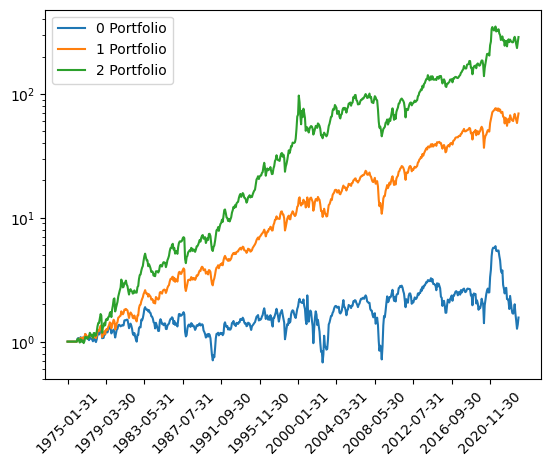

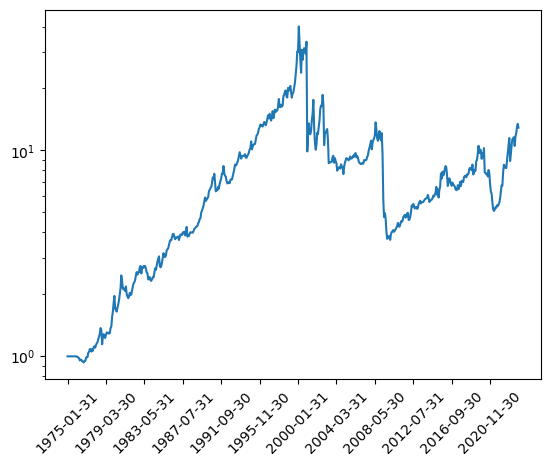

In [6]:
# Portfolio
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index
    (dfs['mom_prc'] * dfs['idx_vol_threshold'],
     quantiles=np.array([0.3, 0.7])
     ),
    
)

## Comp Funda

In [7]:
comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})
comp_funda_og['cusip'] = comp_funda_og['cusip'].apply(lambda x: str(x)[:8])
comp_funda_og = comp_funda_og[comp_funda_og.datafmt == 'STD'].reset_index(drop=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_33600\1687239459.py:1: DtypeWarning: Columns (9,11,12,13,17,18,23,27,31,34,35,36,921,947,948) have mixed types. Specify dtype option on import or set low_memory=False.
  comp_funda_og = pd.read_csv("comp_funda.csv", index_col=0).rename(columns={"datadate": "date"})


c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


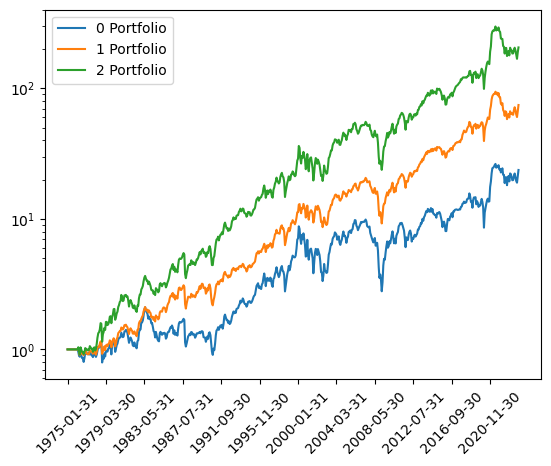

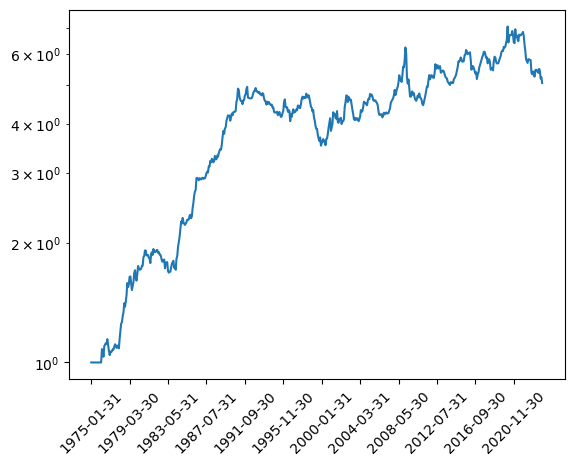

In [14]:
# Portfolio
dfs['pm_pct'] = get_pm_df(comp_funda_og, dfs['ret'])
feature = 'pm_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


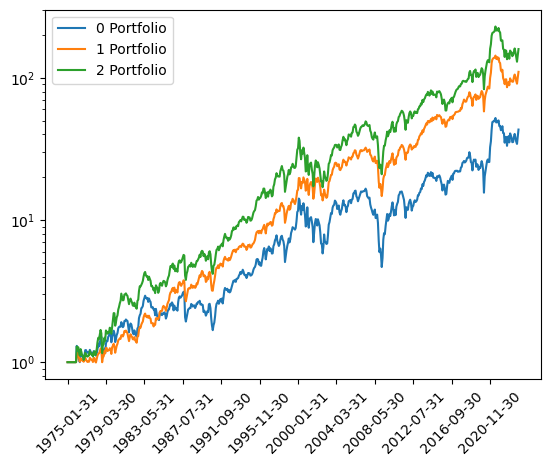

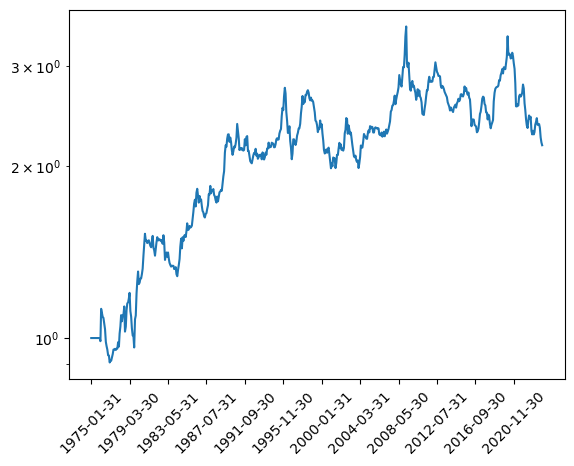

In [10]:
# Portfolio
dfs['eps_pct'] = get_eps_df(comp_funda_og, dfs['ret'], )
feature = 'eps_pct'
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        dfs[feature] * dfs['idx_vol_threshold'], 
        quantiles=np.array([0.3, 0.7])
        )
)